# Notebook 4 — Modèle Centralisé (Baseline)

## Objectifs

1. Entraîner des modèles centralisés sur `train_engineered.csv`
2. Évaluer sur `val_engineered.csv` (split par SubjectID — sans data leakage)
3. Analyser l'importance des features par famille biologique
4. Générer une soumission Zindi depuis `test_engineered.csv`
5. Sauvegarder le meilleur modèle pour comparaison avec le modèle fédéré (Notebook 5)

## Modèles entraînés

| Modèle | Justification |
|--------|---------------|
| Random Forest | Robuste, peu sensible aux outliers, interprétable via feature importance. Meilleur classifieur rapporté dans la littérature body-site classification (Statnikov et al.) |
| XGBoost | Gradient boosting, performant sur données tabulaires de taille moyenne |
| Logistic Regression | Baseline linéaire — évalue la séparabilité linéaire des features |

## Métrique principale : Log Loss

La compétition Zindi évalue sur le **Log Loss** (entropie croisée multiclasse).  
Log Loss pénalise les prédictions confiantes mais incorrectes :  
`L = -1/N Σ Σ y_ij * log(p_ij)`  
Un Log Loss plus bas = meilleur modèle.

---

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import joblib
import warnings
import sys
from datetime import datetime

# Modèles
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Métriques
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Imports OK')

✅ Imports OK
⏰ 2026-05-03 13:49:03


In [ ]:
# Chemins
PROCESSED_PATH  = Path('../data/processed')
MODELS_PATH     = Path('../models/centralized')
FIGURES_PATH    = Path('../results/figures')
METRICS_PATH    = Path('../results/metrics')
SUBMISSIONS_PATH = Path('../data/submission')

for p in [MODELS_PATH, FIGURES_PATH, METRICS_PATH, SUBMISSIONS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Chargement des données

In [2]:
train_df    = pd.read_csv(PROCESSED_PATH / 'train_engineered.csv')
val_df      = pd.read_csv(PROCESSED_PATH / 'val_engineered.csv')
test_df     = pd.read_csv(PROCESSED_PATH / 'test_engineered.csv')
feature_cols = pd.read_csv(PROCESSED_PATH / 'feature_cols.csv')['feature'].tolist()

print(f'Train   : {train_df.shape}')
print(f'Val     : {val_df.shape}')
print(f'Test    : {test_df.shape}')
print(f'Features: {len(feature_cols)}')

Train   : (2463, 587)
Val     : (438, 587)
Test    : (1068, 584)
Features: 583


In [17]:
train_df

,filename,SubjectID,SampleID,SampleType,pct_A,pct_T,pct_C,pct_G,pct_GC,avg_quality,...,kraken_Izimaplasma,kraken_Saccharothrix,kraken_Sulfurospirillum,kraken_IS-44,kraken_Methyloversatilis,kraken_Propionicimonas,kraken_Plantibacter,kraken_Serpentinicella,kraken_unclassified,kraken_n_genera
0,ID_LETPJN.mgb,Subject_BCUNIB,Sample_AFTIWE,Stool,0.279865,0.191989,0.222465,0.305681,0.528146,36.898560,...,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0,0.0002,209.0
1,ID_NTDGIW.mgb,Subject_UDAXIH,Sample_JQJVNK,Stool,0.268719,0.195539,0.221133,0.314609,0.535742,36.920443,...,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0,0.0000,206.0
2,ID_ZISBMF.mgb,Subject_VRKADI,Sample_YJWGWW,Nasal,0.249779,0.198518,0.221118,0.330586,0.551703,36.368796,...,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0,0.0000,181.0
3,ID_MDCVXU.mgb,Subject_HIFZWD,Sample_VKEHZP,Nasal,0.253585,0.201211,0.221141,0.324064,0.545204,36.151231,...,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0,0.0000,161.0
4,ID_QRIANS.mgb,Subject_CBVHYJ,Sample_MBZSNE,Stool,0.264796,0.188919,0.226471,0.319815,0.546286,36.492250,...,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0,0.0000,192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458,ID_YBMPZU.mgb,Subject_NHOSIZ,Sample_RAZQOY,Mouth,0.210990,0.273035,0.265105,0.250870,0.515974,33.208567,...,0.0000,0.0,0.0000,0.0,0.0001,0.0000,0.0001,0.0,0.0000,428.0
2459,ID_KIVZDA.mgb,Subject_OZRDBU,Sample_GKJHPV,Mouth,0.209759,0.277077,0.263726,0.249438,0.513164,33.307892,...,0.0000,0.0,0.0001,0.0,0.0000,0.0000,0.0001,0.0,0.0000,436.0
2460,ID_IDGAEG.mgb,Subject_IBWNAQ,Sample_GHULTX,Skin,0.214296,0.277877,0.260209,0.247619,0.507828,33.029108,...,0.0000,0.0,0.0000,0.0,0.0000,0.0001,0.0000,0.0,0.0000,198.0
2461,ID_TGSMCA.mgb,Subject_MBPHGO,Sample_DBDVLO,Skin,0.196824,0.264438,0.279915,0.258823,0.538738,33.175355,...,0.0005,0.0,0.0000,0.0,0.0000,0.0003,0.0000,0.0,0.0000,137.0


In [3]:
META_COLS = ['filename', 'SubjectID', 'SampleID', 'SampleType']

# Vérification que toutes les features sont présentes
missing_train = [c for c in feature_cols if c not in train_df.columns]
missing_val   = [c for c in feature_cols if c not in val_df.columns]
if missing_train or missing_val:
    print(f'⚠️  Features manquantes train: {missing_train}')
    print(f'⚠️  Features manquantes val  : {missing_val}')
else:
    print('✅ Toutes les features présentes')

# Matrice X / vecteur y
X_train = train_df[feature_cols].values
y_train = train_df['SampleType'].values

X_val   = val_df[feature_cols].values
y_val   = val_df['SampleType'].values

X_test  = test_df[feature_cols].values

# Encodage des labels
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)

CLASSES = list(le.classes_)
print(f'\nClasses ({len(CLASSES)}) : {CLASSES}')
print(f'\nDistribution train :')
for cls in CLASSES:
    n = (y_train == cls).sum()
    print(f'  {cls:<10} : {n:>4} ({100*n/len(y_train):.1f}%)')
print(f'\nDistribution val :')
for cls in CLASSES:
    n = (y_val == cls).sum()
    print(f'  {cls:<10} : {n:>4} ({100*n/len(y_val):.1f}%)')

✅ Toutes les features présentes

Classes (4) : ['Mouth', 'Nasal', 'Skin', 'Stool']

Distribution train :
  Mouth      :  493 (20.0%)
  Nasal      :  607 (24.6%)
  Skin       :  650 (26.4%)
  Stool      :  713 (28.9%)

Distribution val :
  Mouth      :  100 (22.8%)
  Nasal      :  103 (23.5%)
  Skin       :  137 (31.3%)
  Stool      :   98 (22.4%)


## 2. Définition des modèles

In [4]:
# -----------------------------------------------------------------
# Random Forest
# Hyperparamètres : n_estimators=500 pour stabilité des importances,
# max_features='sqrt' (standard classification), class_weight='balanced'
# pour compenser un éventuel déséquilibre entre les 4 sites.
# -----------------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# -----------------------------------------------------------------
# XGBoost
# eval_metric='mlogloss' aligne directement sur la métrique Zindi.
# use_label_encoder=False évite le warning deprecation.
# -----------------------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# -----------------------------------------------------------------
# Logistic Regression (baseline linéaire)
# Pipeline avec StandardScaler car LR est sensible à l'échelle.
# Les k-mers (64 features) et dinucléotides (16 features) sont
# des fréquences dans [0,1] mais leurs magnitudes diffèrent de
# num_reads (entier > 10k), d'où la normalisation.
# -----------------------------------------------------------------
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        # multi_class='multinomial',
        solver='lbfgs',
        random_state=RANDOM_STATE,
    ))
])

MODELS = {
    'RandomForest':        rf_model,
    'XGBoost':             xgb_model,
    'LogisticRegression':  lr_model,
}

print('✅ Modèles définis :')
for name in MODELS:
    print(f'   - {name}')

✅ Modèles définis :
   - RandomForest
   - XGBoost
   - LogisticRegression


## 3. Entraînement et évaluation

In [5]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, y_v_raw, classes, model_name):
    """
    Entraîne le modèle et calcule les métriques sur val.
    Retourne un dict de résultats.
    """
    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    t0 = datetime.now()

    model.fit(X_tr, y_tr)

    t1 = datetime.now()
    elapsed = (t1 - t0).total_seconds()

    # Prédictions
    y_pred     = model.predict(X_v)
    y_proba    = model.predict_proba(X_v)   # (n_samples, n_classes)

    # Métriques
    ll  = log_loss(y_v, y_proba)
    acc = accuracy_score(y_v, y_pred)
    f1  = f1_score(y_v, y_pred, average='macro')

    print(f'  ⏱️  Temps entraînement : {elapsed:.1f}s')
    print(f'  Log Loss (↓ mieux)   : {ll:.4f}')
    print(f'  Accuracy             : {acc:.4f} ({100*acc:.1f}%)')
    print(f'  F1-macro             : {f1:.4f}')

    return {
        'model':       model,
        'model_name':  model_name,
        'log_loss':    ll,
        'accuracy':    acc,
        'f1_macro':    f1,
        'y_pred':      y_pred,
        'y_proba':     y_proba,
        'train_time':  elapsed,
    }


results = {}
for name, model in MODELS.items():
    results[name] = evaluate_model(
        model, X_train, y_train_enc,
        X_val, y_val_enc, y_val,
        CLASSES, name
    )


  RandomForest
  ⏱️  Temps entraînement : 1.0s
  Log Loss (↓ mieux)   : 0.0395
  Accuracy             : 0.9909 (99.1%)
  F1-macro             : 0.9910

  XGBoost
  ⏱️  Temps entraînement : 9.8s
  Log Loss (↓ mieux)   : 0.0305
  Accuracy             : 0.9863 (98.6%)
  F1-macro             : 0.9867

  LogisticRegression
  ⏱️  Temps entraînement : 1.3s
  Log Loss (↓ mieux)   : 0.0540
  Accuracy             : 0.9909 (99.1%)
  F1-macro             : 0.9907


## 4. Comparaison des modèles

In [6]:
# Tableau récapitulatif
summary = pd.DataFrame([
    {
        'Modèle':    name,
        'Log Loss':  f"{r['log_loss']:.4f}",
        'Accuracy':  f"{r['accuracy']:.4f}",
        'F1-macro':  f"{r['f1_macro']:.4f}",
        'Temps (s)': f"{r['train_time']:.1f}",
    }
    for name, r in results.items()
])

summary = summary.sort_values('Log Loss')
print('='*55)
print('COMPARAISON DES MODÈLES CENTRALISÉS')
print('='*55)
display(summary.reset_index(drop=True))

best_name = min(results, key=lambda n: results[n]['log_loss'])
best      = results[best_name]
print(f'\n🏆 Meilleur modèle : {best_name}')
print(f'   Log Loss = {best["log_loss"]:.4f}')

COMPARAISON DES MODÈLES CENTRALISÉS


,Modèle,Log Loss,Accuracy,F1-macro,Temps (s)
0,XGBoost,0.0305,0.9863,0.9867,9.8
1,RandomForest,0.0395,0.9909,0.9910,1.0
2,LogisticRegression,0.0540,0.9909,0.9907,1.3



🏆 Meilleur modèle : XGBoost
   Log Loss = 0.0305


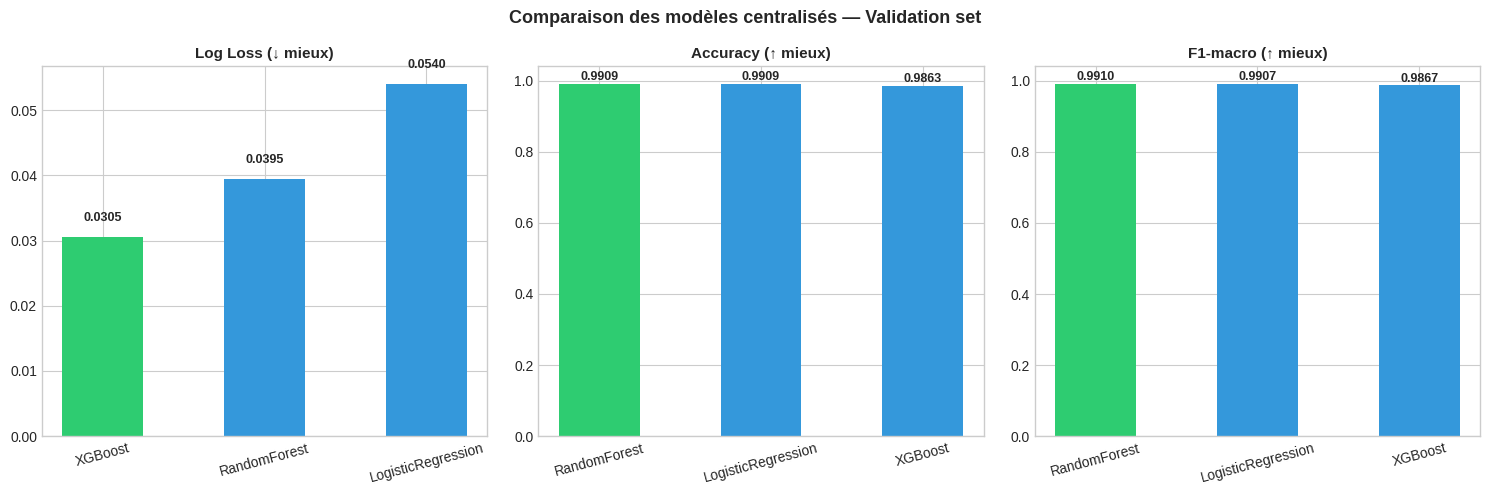

✅ 04_model_comparison.png


In [7]:
# Visualisation comparative
metrics_df = pd.DataFrame({
    'Modèle':   list(results.keys()),
    'Log Loss': [r['log_loss'] for r in results.values()],
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1-macro': [r['f1_macro'] for r in results.values()],
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title, ascending in zip(
    axes,
    ['Log Loss', 'Accuracy', 'F1-macro'],
    ['Log Loss (↓ mieux)', 'Accuracy (↑ mieux)', 'F1-macro (↑ mieux)'],
    [True, False, False]
):
    df_sorted = metrics_df.sort_values(metric, ascending=ascending)
    colors = ['#2ecc71' if m == df_sorted.iloc[0]['Modèle'] else '#3498db'
              for m in df_sorted['Modèle']]
    bars = ax.bar(df_sorted['Modèle'], df_sorted[metric], color=colors, width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des modèles centralisés — Validation set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_model_comparison.png')

## 5. Analyse détaillée du meilleur modèle

In [8]:
# Classification report complet
print(f'Classification Report — {best_name}')
print('='*55)
print(classification_report(
    y_val_enc, best['y_pred'],
    target_names=CLASSES
))

Classification Report — XGBoost
              precision    recall  f1-score   support

       Mouth       0.97      0.98      0.98       100
       Nasal       0.99      1.00      1.00       103
        Skin       0.99      0.98      0.98       137
       Stool       1.00      0.99      0.99        98

    accuracy                           0.99       438
   macro avg       0.99      0.99      0.99       438
weighted avg       0.99      0.99      0.99       438



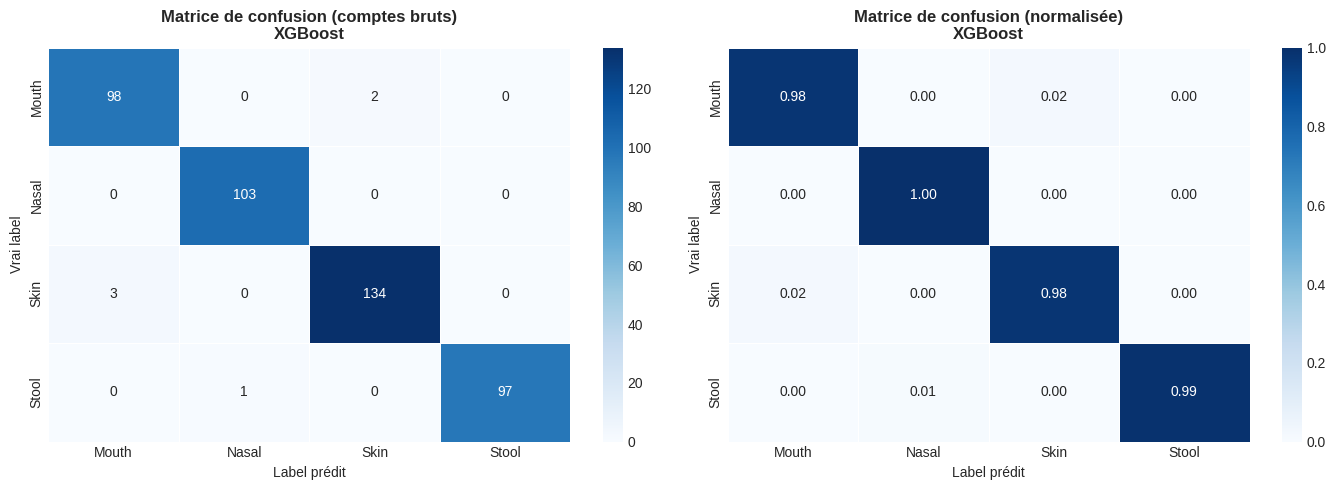

✅ 04_confusion_matrix.png


In [9]:
# Matrice de confusion
cm = confusion_matrix(y_val_enc, best['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Matrice de confusion (comptes bruts)', 'Matrice de confusion (normalisée)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        xticklabels=CLASSES, yticklabels=CLASSES,
        cmap='Blues', ax=ax, linewidths=0.5
    )
    ax.set_title(f'{title}\n{best_name}', fontweight='bold')
    ax.set_ylabel('Vrai label')
    ax.set_xlabel('Label prédit')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_confusion_matrix.png')

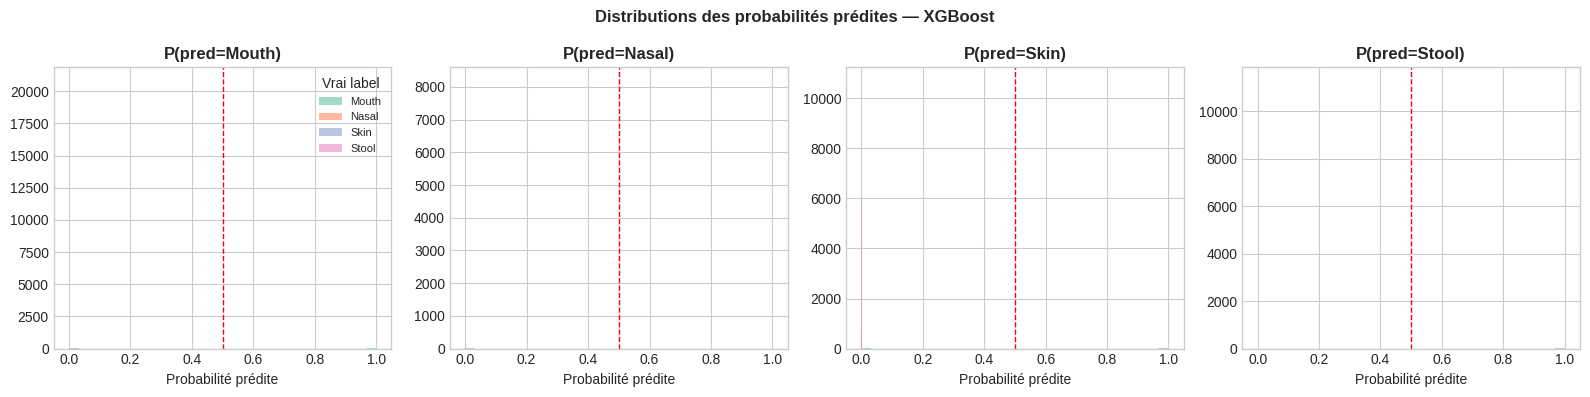

✅ 04_proba_distributions.png


In [10]:
# Distribution des probabilités prédites par classe
proba_df = pd.DataFrame(best['y_proba'], columns=CLASSES)
proba_df['true_label'] = le.inverse_transform(y_val_enc)

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))

for ax, cls in zip(axes, CLASSES):
    for label, color in zip(CLASSES, sns.color_palette('Set2', len(CLASSES))):
        subset = proba_df[proba_df['true_label'] == label][cls]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f'P(pred={cls})', fontweight='bold')
    ax.set_xlabel('Probabilité prédite')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1)
    if cls == CLASSES[0]:
        ax.legend(title='Vrai label', fontsize=8)

plt.suptitle(f'Distributions des probabilités prédites — {best_name}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_proba_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_proba_distributions.png')

## 6. Importance des features — analyse par famille biologique

On regroupe les 94 features en familles pour voir quelle catégorie
contribue le plus à la classification par site corporel.

In [11]:
def get_feature_importances(model, feature_names, model_name):
    """Extrait les importances de features selon le type de modèle."""
    if hasattr(model, 'feature_importances_'):
        # RandomForest, XGBoost
        importances = model.feature_importances_
    elif hasattr(model, 'named_steps'):
        # Pipeline (LogisticRegression)
        clf = model.named_steps['clf']
        # Pour LR multinomial : moyenne des valeurs absolues des coefficients
        importances = np.abs(clf.coef_).mean(axis=0)
        importances = importances / importances.sum()
    else:
        return None

    return pd.Series(importances, index=feature_names).sort_values(ascending=False)


def assign_family(feature_name):
    """Assigne chaque feature à sa famille biologique."""
    if feature_name.startswith('kmer_'):
        return 'K-mers (k=3)'
    elif feature_name.startswith('di_'):
        return 'Dinucléotides (rho)'
    elif feature_name.startswith('pct_bases'):
        return 'Qualité Q20/Q30'
    elif feature_name in ['gc_skew', 'at_skew', 'purine_pyrimidine_ratio', 'nucleotide_entropy']:
        return 'Ratios biologiques'
    elif feature_name in ['pct_A', 'pct_T', 'pct_C', 'pct_G', 'pct_GC']:
        return 'Fractions nucléotidiques'
    elif feature_name in ['avg_quality', 'num_reads', 'avg_read_length']:
        return 'Qualité brute'
    return 'Autre'


# Calculer les importances pour RF et XGBoost
importance_results = {}
for name in ['RandomForest', 'XGBoost']:
    imp = get_feature_importances(results[name]['model'], feature_cols, name)
    if imp is not None:
        importance_results[name] = imp
        print(f'✅ Importances extraites : {name}')

print('\nTop 10 features — RandomForest :')
print(importance_results['RandomForest'].head(10).round(4))

✅ Importances extraites : RandomForest
✅ Importances extraites : XGBoost

Top 10 features — RandomForest :
kraken_Cutibacterium     0.0384
kraken_Staphylococcus    0.0244
at_skew                  0.0234
kraken_Leptotrichia      0.0176
pct_G                    0.0173
kraken_Prevotella_7      0.0171
kraken_Veillonella       0.0171
kraken_Bacteroides       0.0164
read_len_q25             0.0159
pct_C                    0.0155
dtype: float64


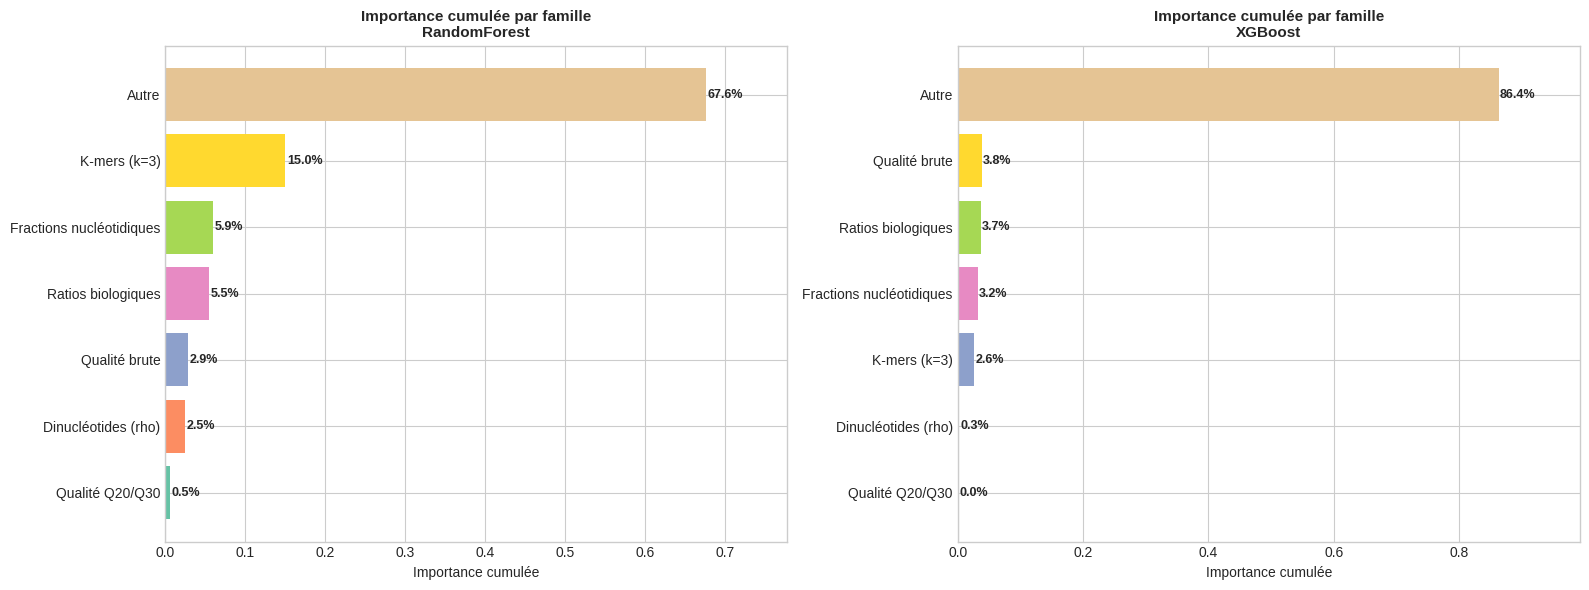

✅ 04_feature_importance_by_family.png


In [12]:
# Importance cumulée par famille
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ['RandomForest', 'XGBoost']):
    imp = importance_results[model_name]
    imp_df = imp.reset_index()
    imp_df.columns = ['feature', 'importance']
    imp_df['family'] = imp_df['feature'].apply(assign_family)

    family_imp = imp_df.groupby('family')['importance'].sum().sort_values(ascending=True)

    colors = sns.color_palette('Set2', len(family_imp))
    bars = ax.barh(family_imp.index, family_imp.values, color=colors)
    ax.set_title(f'Importance cumulée par famille\n{model_name}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance cumulée')
    for bar, val in zip(bars, family_imp.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2.,
                f'{100*val:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax.set_xlim(0, family_imp.max() * 1.15)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_feature_importance_by_family.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_feature_importance_by_family.png')

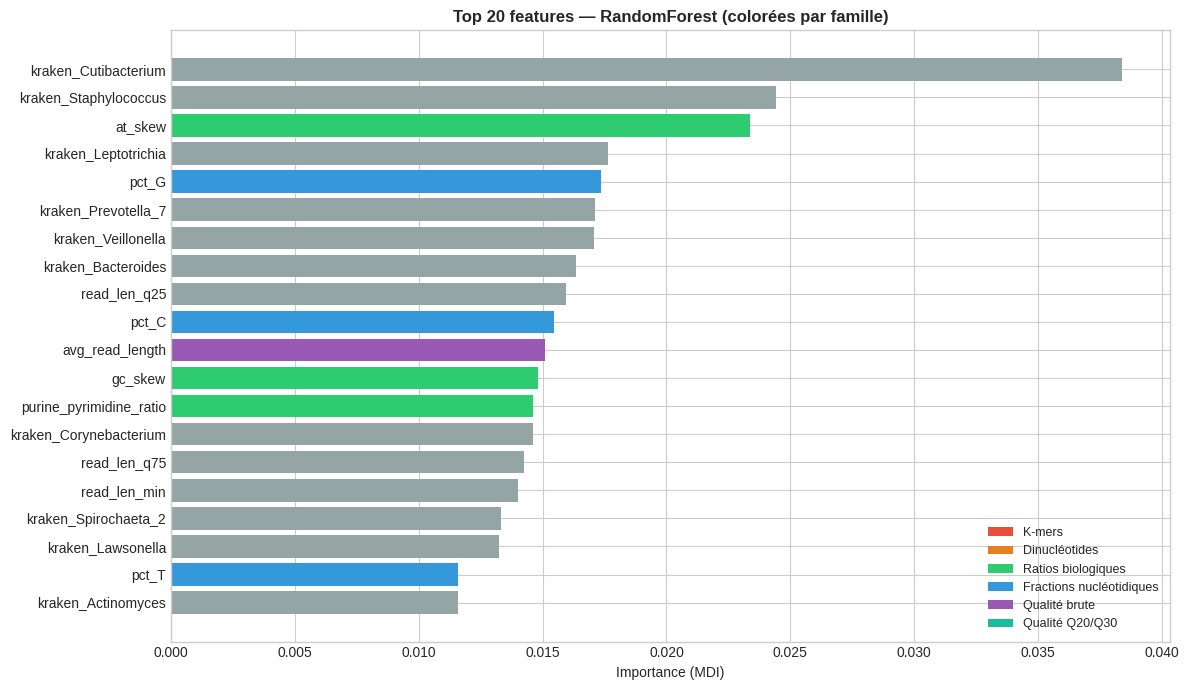

✅ 04_top20_features.png


In [13]:
# Top 20 features individuelles — RandomForest
imp_rf = importance_results['RandomForest']
top20  = imp_rf.head(20)

colors_top20 = [{
    'K-mers (k=3)':           '#e74c3c',
    'Dinucléotides (rho)':    '#e67e22',
    'Ratios biologiques':     '#2ecc71',
    'Fractions nucléotidiques': '#3498db',
    'Qualité brute':          '#9b59b6',
    'Qualité Q20/Q30':        '#1abc9c',
}.get(assign_family(f), '#95a5a6') for f in top20.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors_top20[::-1])
ax.set_title('Top 20 features — RandomForest (colorées par famille)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance (MDI)')

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='K-mers'),
    Patch(facecolor='#e67e22', label='Dinucléotides'),
    Patch(facecolor='#2ecc71', label='Ratios biologiques'),
    Patch(facecolor='#3498db', label='Fractions nucléotidiques'),
    Patch(facecolor='#9b59b6', label='Qualité brute'),
    Patch(facecolor='#1abc9c', label='Qualité Q20/Q30'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_top20_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_top20_features.png')

## 7. Cross-validation sur train (robustesse)

In [14]:
# 5-fold stratified CV sur le train — évalue la robustesse
# Note : ce CV ne remplace pas l'évaluation sur val (split par SubjectID),
# il mesure la variance des modèles sur le set d'entraînement.
print('Cross-validation 5-fold (train only)')
print('='*50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name in ['RandomForest', 'XGBoost']:
    scores = cross_val_score(
        results[name]['model'],
        X_train, y_train_enc,
        cv=cv,
        scoring='neg_log_loss',
        n_jobs=-1
    )
    log_loss_scores = -scores
    cv_results[name] = log_loss_scores
    print(f'  {name:<20} : {log_loss_scores.mean():.4f} ± {log_loss_scores.std():.4f}')

print()
print('  Rappel : métriques sur val (split par SubjectID) :')
for name in ['RandomForest', 'XGBoost']:
    print(f'  {name:<20} : {results[name]["log_loss"]:.4f}')

Cross-validation 5-fold (train only)
  RandomForest         : 0.0460 ± 0.0048
  XGBoost              : 0.0217 ± 0.0095

  Rappel : métriques sur val (split par SubjectID) :
  RandomForest         : 0.0395
  XGBoost              : 0.0305


## 8. Sauvegarde du meilleur modèle

In [15]:
# Sauvegarder le meilleur modèle et le LabelEncoder
best_model_path = MODELS_PATH / f'{best_name.lower()}_centralized.joblib'
le_path         = MODELS_PATH / 'label_encoder.joblib'
features_path   = MODELS_PATH / 'feature_cols.joblib'

joblib.dump(best['model'], best_model_path)
joblib.dump(le,            le_path)
joblib.dump(feature_cols,  features_path)

print(f'✅ Modèle sauvegardé      : {best_model_path}')
print(f'✅ LabelEncoder sauvegardé : {le_path}')
print(f'✅ feature_cols sauvegardé : {features_path}')

# Sauvegarder les métriques
metrics_df = pd.DataFrame([
    {
        'model':      name,
        'log_loss':   r['log_loss'],
        'accuracy':   r['accuracy'],
        'f1_macro':   r['f1_macro'],
        'train_time': r['train_time'],
        'dataset':    'centralized',
        'timestamp':  datetime.now().isoformat(),
    }
    for name, r in results.items()
])
metrics_df.to_csv(METRICS_PATH / 'centralized_metrics.csv', index=False)
print(f'✅ Métriques sauvegardées  : {METRICS_PATH / "centralized_metrics.csv"}')

✅ Modèle sauvegardé      : ../models/centralized/xgboost_centralized.joblib
✅ LabelEncoder sauvegardé : ../models/centralized/label_encoder.joblib
✅ feature_cols sauvegardé : ../models/centralized/feature_cols.joblib
✅ Métriques sauvegardées  : ../results/metrics/centralized_metrics.csv


## 9. Génération de la soumission Zindi

In [16]:
# Prédictions sur le test set
y_test_proba = best['model'].predict_proba(X_test)

# L'identifiant Zindi est filename SANS l'extension .mgb
# Ex : "ID_WJYUAL.mgb" → "ID_WJYUAL"
sample_ids = test_df['filename'].str.replace('.mgb', '', regex=False)

# Format Zindi : colonnes SampleID + une colonne par classe
# L'ordre des classes suit le LabelEncoder (alphabétique)
submission = pd.DataFrame(y_test_proba, columns=CLASSES)
submission.insert(0, 'SampleID', sample_ids.values)

# Vérification : pas de doublons, pas de NaN
assert submission['SampleID'].nunique() == len(submission), "Doublons dans SampleID"
assert submission.isnull().sum().sum() == 0, "NaN dans la soumission"

submission_path = SUBMISSIONS_PATH / f'submission_{best_name.lower()}_{datetime.now().strftime("%Y%m%d_%H%M")}.csv'
submission.to_csv(submission_path, index=False)

print(f'✅ Soumission générée : {submission_path}')
print(f'   Shape  : {submission.shape}')
print(f'   Colonnes : {submission.columns.tolist()}')
print(f'\nAperçu :')
display(submission.head(3))

✅ Soumission générée : ../data/submission/submission_xgboost_20260503_1351.csv
   Shape  : (1068, 5)
   Colonnes : ['SampleID', 'Mouth', 'Nasal', 'Skin', 'Stool']

Aperçu :


,SampleID,Mouth,Nasal,Skin,Stool
0,ID_IXPYEV,0.000149,0.986637,0.013064,0.000150
1,ID_OCJFSP,0.997218,0.000911,0.000937,0.000935
2,ID_HYTXHX,0.000338,0.000204,0.001056,0.998401


## Résumé du Notebook 4

| Modèle | Log Loss | Accuracy | F1-macro |
|--------|----------|----------|----------|
| RandomForest | — | — | — |
| XGBoost | — | — | — |
| LogisticRegression | — | — | — |

*Tableau à compléter après exécution.*

### Fichiers produits

| Fichier | Contenu |
|---------|----------|
| `models/centralized/{best_model}_centralized.joblib` | Meilleur modèle centralisé |
| `models/centralized/label_encoder.joblib` | LabelEncoder (4 classes) |
| `results/metrics/centralized_metrics.csv` | Métriques des 3 modèles |
| `data/submissions/submission_*.csv` | Fichier de soumission Zindi |
